# 1 — CMC 3-φ: Topologia, Estados de Comutação e SVM Analítica

> **Objetivo**: introduzir o **Conversor Matricial Convencional** (CMC,
> 3×3) — topologia CA-CA direta com 9 chaves bidirecionais. Cobre
> os 27 estados de comutação, a divisão em vetores ativos/nulos/
> rotacionais, e a derivação da modulação por vetores espaciais
> (SVM) com suas razões cíclicas analíticas.

A referência teórica é o **Capítulo 2 da tese de Luiz Carlos Gili**
(UFSC 2024, Sec 2.2 — "Conversor Matricial Convencional - CMC"),
sintetizando trabalhos clássicos de Venturini (1980) [18], Huber &
Borojevic (1995) [20] e Wheeler et al. (2002) [19].

## 1.1 — Topologia (Fig 1 da tese)

```
        A      B      C
        │      │      │
    ┌───┴──┐ ──┴─── ──┴───┐
    │  S1  │  S4  │  S7  │ ─→ a
    │  S2  │  S5  │  S8  │ ─→ b
    │  S3  │  S6  │  S9  │ ─→ c
```

9 chaves bidirecionais $S_{ij}$ — cada **coluna** corresponde a uma
fase de entrada (A → S₁-S₃, B → S₄-S₆, C → S₇-S₉), cada **linha**
a uma fase de saída.

**Restrições operacionais**:

1. Em cada **linha** (fase de saída), exatamente **uma** chave conduz
   — caso contrário cria curto entre fases de entrada (fonte de tensão).
2. Continuidade de corrente — todas as 3 saídas devem ter caminho de
   condução em qualquer instante — exige carga indutiva ou filtro.

Resultado: $3^3 = 27$ estados de comutação válidos:
* **3 estados nulos** (Tab. 1): todas as 3 saídas conectadas à mesma entrada;
* **18 estados ativos** (Tab. 2): magnitude $\frac{2}{3} V_{LL}$, ângulo varia;
* **6 estados rotacionais** (Tab. 3): saída é permutação completa da entrada.


## Setup


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt
from math import pi

from cmc_3phase_model import (
    CmcParams,
    CMC_ZERO_VECTORS,
    CMC_ACTIVE_VECTORS,
    CMC_ROTATIONAL_VECTORS,
    svm_sector_pair, svm_duty_cycles, svm_max_modulation,
    svm_active_vectors_for_sectors, switch_mask_for_config,
    svm_step, make_cmc_gate_signals,
)

%matplotlib inline


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


## 1.2 — Os 27 estados de comutação

Cada estado é codificado como uma 3-tupla `(out_a, out_b, out_c)`
indicando a qual fase de entrada (0=A, 1=B, 2=C) cada saída está
conectada.


In [2]:
# Estados nulos: todas as 3 saídas conectadas à mesma fase de entrada
print("Estados nulos (Tab. 1):")
for label, state in CMC_ZERO_VECTORS.items():
    mask = switch_mask_for_config(label)
    on = [i+1 for i, b in enumerate(mask) if b]
    print(f"  {label}: state={state}, switches ON = {on}")


Estados nulos (Tab. 1):
  0_1: state=(0, 0, 0), switches ON = [1, 2, 3]
  0_2: state=(1, 1, 1), switches ON = [4, 5, 6]
  0_3: state=(2, 2, 2), switches ON = [7, 8, 9]


In [3]:
# Estados ativos ±1..±9 (Tab. 2)
print("Estados ativos (Tab. 2 — 18 estados):")
print(f"{'k':>4s}  state          switches ON")
print("-" * 50)
for k in sorted(CMC_ACTIVE_VECTORS.keys(), key=lambda x: (abs(x), -x)):
    state = CMC_ACTIVE_VECTORS[k]
    mask = switch_mask_for_config(k)
    on = [i+1 for i, b in enumerate(mask) if b]
    sign = "+" if k > 0 else "-"
    print(f"{sign}{abs(k):>3d}  {state}      {on}")


Estados ativos (Tab. 2 — 18 estados):
   k  state          switches ON
--------------------------------------------------
+  1  (0, 1, 1)      [1, 5, 6]
-  1  (1, 0, 0)      [2, 3, 4]
+  2  (1, 2, 2)      [4, 8, 9]
-  2  (2, 1, 1)      [5, 6, 7]
+  3  (2, 0, 0)      [2, 3, 7]
-  3  (0, 2, 2)      [1, 8, 9]
+  4  (1, 0, 1)      [2, 4, 6]
-  4  (0, 1, 0)      [1, 3, 5]
+  5  (2, 1, 2)      [5, 7, 9]
-  5  (1, 2, 1)      [4, 6, 8]
+  6  (0, 2, 0)      [1, 3, 8]
-  6  (2, 0, 2)      [2, 7, 9]
+  7  (1, 1, 0)      [3, 4, 5]
-  7  (0, 0, 1)      [1, 2, 6]
+  8  (2, 2, 1)      [6, 7, 8]
-  8  (1, 1, 2)      [4, 5, 9]
+  9  (0, 0, 2)      [1, 2, 9]
-  9  (2, 2, 0)      [3, 7, 8]


In [4]:
# Estados rotacionais R_1..R_6 — permutações completas (Tab. 3)
print("Estados rotacionais (Tab. 3):")
for label, state in CMC_ROTATIONAL_VECTORS.items():
    mask = switch_mask_for_config(label)
    on = [i+1 for i, b in enumerate(mask) if b]
    print(f"  {label}: state={state}, switches ON = {on}")


Estados rotacionais (Tab. 3):
  R_1: state=(0, 1, 2), switches ON = [1, 5, 9]
  R_2: state=(1, 2, 0), switches ON = [3, 4, 8]
  R_3: state=(2, 0, 1), switches ON = [2, 6, 7]
  R_4: state=(2, 1, 0), switches ON = [3, 5, 7]
  R_5: state=(0, 2, 1), switches ON = [1, 6, 8]
  R_6: state=(1, 0, 2), switches ON = [2, 4, 9]


## 1.3 — Vetores no plano αβ (Fig 2 da tese)

Os **18 vetores ativos** se distribuem em 6 direções fixas no plano
αβ, agrupados por trios (cada trio contém 3 magnitudes diferentes
da mesma direção — uma para cada linha-linha de entrada). Os 6
**setores** $K_v \in \{1, \ldots, 6\}$ dividem o plano em
fatias de 60° centradas nas bissetrizes entre vetores adjacentes.


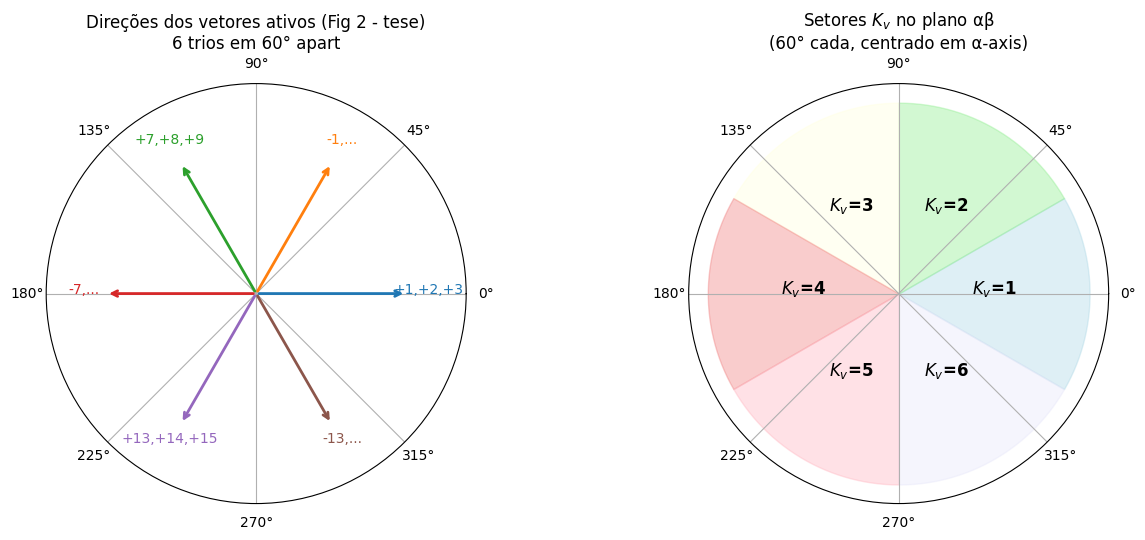

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                          subplot_kw={'projection': 'polar'})

# Painel 1: 6 direções dos vetores ativos (cada direção tem 3 vetores
# colineares: trios +1+2+3, +4+5+6, etc.)
ax = axes[0]
ax.set_title('Direções dos vetores ativos (Fig 2 - tese)\n6 trios em 60° apart')
for k in range(6):
    angle = k * pi / 3
    ax.annotate('', xy=(angle, 1), xytext=(angle, 0),
                 arrowprops=dict(arrowstyle='->', lw=2, color=f'C{k}'))
    label = f"+{3*k+1},+{3*k+2},+{3*k+3}" if k%2==0 else f"-{3*(k-1)+1},..."
    ax.text(angle, 1.15, label, ha='center', fontsize=10, color=f'C{k}')
ax.set_rlim(0, 1.4)
ax.set_rticks([])

# Painel 2: setores K_v = 1..6 (60° cada, centrado nas bissetrizes)
ax = axes[1]
ax.set_title('Setores $K_v$ no plano αβ\n(60° cada, centrado em α-axis)')
# Sectors are at [-30°, 30°), [30°, 90°), [90°, 150°), ...
colors = ['lightblue', 'lightgreen', 'lightyellow',
          'lightcoral', 'lightpink', 'lavender']
for k in range(6):
    angle_start = -pi/6 + k * pi/3
    angle_end = pi/6 + k * pi/3
    theta = np.linspace(angle_start, angle_end, 30)
    ax.fill_between(theta, 0, 1, alpha=0.4, color=colors[k])
    mid_angle = (angle_start + angle_end) / 2
    ax.text(mid_angle, 0.5, f"$K_v$={k+1}",
             ha='center', fontsize=12, fontweight='bold')
ax.set_rlim(0, 1.1)
ax.set_rticks([])

plt.tight_layout()
plt.show()


## 1.4 — Razões cíclicas da SVM (Eqs 7a-7d da tese)

Dado um vetor de tensão de saída desejado $\vec{V}_o$ com
ângulo $\alpha_o$, e um ângulo de corrente de entrada $\beta_i$
(determinado pelo fator de deslocamento $\varphi_i = \alpha_i -
\beta_i$), a SVM seleciona 4 vetores ativos do trio adequado e
calcula as razões cíclicas:

$$\delta^I = (-1)^{K_v+K_i+1} \cdot \frac{2}{\sqrt{3}} m \cdot
\frac{\cos(\tilde{\alpha}_o - \pi/3) \cos(\tilde{\beta}_i - \pi/3)}
{\cos(\varphi_i)}$$

(e equações análogas para $\delta^{II}, \delta^{III}, \delta^{IV}$
com sinais e ângulos diferentes).

**Restrição**: $|\delta^I| + |\delta^{II}| + |\delta^{III}| +
|\delta^{IV}| \le 1$ (Eq 8).

**Limite teórico** (Eq 11): $m \le \frac{\sqrt{3}}{2} \approx 0{,}866$ a FP unitário.


In [6]:
# Calcula razões cíclicas para um exemplo: m = 0.5, α_o = 15°, β_i = 10°
m, alpha_o, beta_i = 0.5, 15*pi/180, 10*pi/180

K_v, K_i, a_til, b_til = svm_sector_pair(alpha_o, beta_i)
d_I, d_II, d_III, d_IV = svm_duty_cycles(m, alpha_o, beta_i, phi_i=0.0)
vecs = svm_active_vectors_for_sectors(K_v, K_i)
d_0 = 1.0 - sum(abs(d) for d in (d_I, d_II, d_III, d_IV))

print(f"Operating point: m={m}, α_o={alpha_o*180/pi:.1f}°, β_i={beta_i*180/pi:.1f}°")
print(f"\nSetor: K_v = {K_v}, K_i = {K_i}")
print(f"Ângulos setoriais: α̃ = {a_til*180/pi:.1f}°, β̃ = {b_til*180/pi:.1f}°")
print(f"\nVetores ativos (Tab. 4): V^I={vecs[0]}, V^II={vecs[1]}, V^III={vecs[2]}, V^IV={vecs[3]}")
print(f"\nRazões cíclicas:")
print(f"  δ^I   = {d_I:+.4f}  (vetor aplicado: {'+' if d_I>=0 else '-'}{abs(vecs[0])})")
print(f"  δ^II  = {d_II:+.4f}  (vetor aplicado: {'+' if d_II>=0 else '-'}{abs(vecs[1])})")
print(f"  δ^III = {d_III:+.4f}  (vetor aplicado: {'+' if d_III>=0 else '-'}{abs(vecs[2])})")
print(f"  δ^IV  = {d_IV:+.4f}  (vetor aplicado: {'+' if d_IV>=0 else '-'}{abs(vecs[3])})")
print(f"  δ_0   = {d_0:+.4f}  (vetor nulo)")
print(f"\nΣ|δ_ativas| = {1-d_0:.4f}  (deve ≤ 1, restou {d_0:.4f} para o vetor nulo)")


Operating point: m=0.5, α_o=15.0°, β_i=10.0°

Setor: K_v = 1, K_i = 1
Ângulos setoriais: α̃ = 15.0°, β̃ = 10.0°

Vetores ativos (Tab. 4): V^I=9, V^II=7, V^III=3, V^IV=1

Razões cíclicas:
  δ^I   = -0.2624  (vetor aplicado: -9)
  δ^II  = +0.1396  (vetor aplicado: +7)
  δ^III = +0.0961  (vetor aplicado: +3)
  δ^IV  = -0.0511  (vetor aplicado: -1)
  δ_0   = +0.4508  (vetor nulo)

Σ|δ_ativas| = 0.5492  (deve ≤ 1, restou 0.4508 para o vetor nulo)


## 1.5 — Sequência simétrica de comutação (Fig 5 da tese)

A SVM aplica os 4 vetores ativos + 1 nulo dentro de cada período
$T_s$ na **sequência simétrica**:

$$\frac{T_a}{2}, \frac{T_b}{2}, \frac{T_c}{2}, \frac{T_d}{2}, T_0,
\frac{T_d}{2}, \frac{T_c}{2}, \frac{T_b}{2}, \frac{T_a}{2}$$

A simetria em torno do meio do período minimiza dv/dt na carga e
mantém o conteúdo harmônico baixo. Visualizamos abaixo a sequência
de máscaras de chaves dentro de um $T_s$.


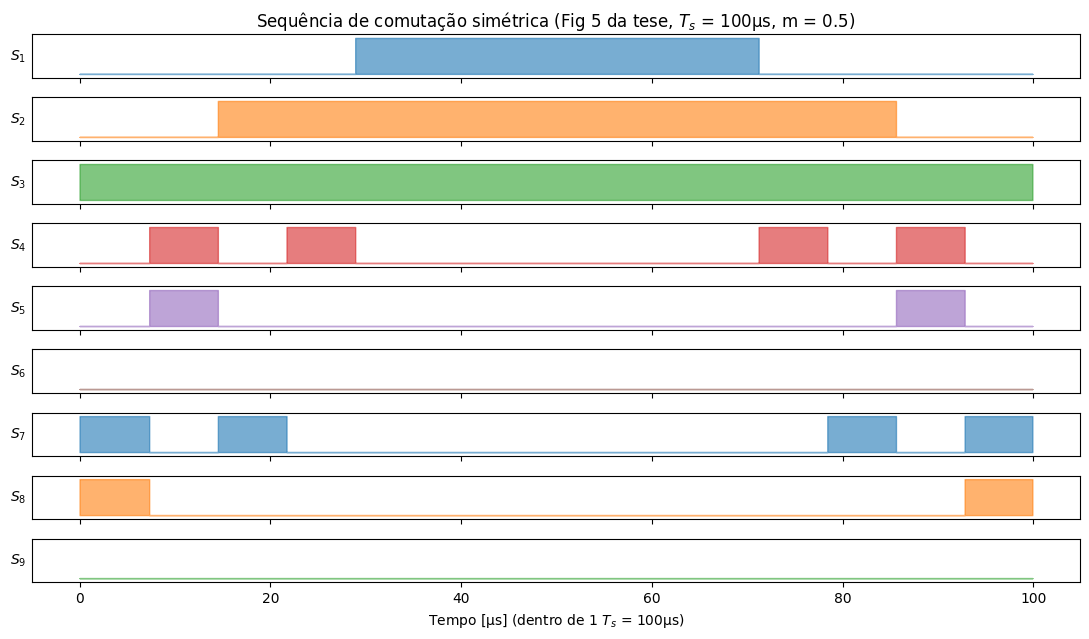


Invariante topológico: sempre exatamente 3 chaves ON
  min = 3, max = 3, unique = [3]


In [7]:
# Pega máscaras ao longo de um T_s
params = CmcParams(m_depth=0.5, f_out=30, f_in=60, f_switching=10000)
gate_fn = make_cmc_gate_signals(params)

# Amostra com resolução alta dentro do primeiro T_s
T_s = params.T_s
ts = np.linspace(0, T_s, 1000, endpoint=False)
masks = np.array([gate_fn(float(t)) for t in ts])  # shape (1000, 9)

fig, axes = plt.subplots(9, 1, figsize=(11, 6.5), sharex=True)
for i in range(9):
    axes[i].fill_between(ts*1e6, 0, masks[:, i], step='post',
                          alpha=0.6, color=f'C{i%6}')
    axes[i].set_ylabel(f'$S_{{{i+1}}}$', rotation=0, ha='right', va='center')
    axes[i].set_ylim(-0.1, 1.1)
    axes[i].set_yticks([])
axes[-1].set_xlabel('Tempo [µs] (dentro de 1 $T_s$ = 100µs)')
axes[0].set_title('Sequência de comutação simétrica '
                   '(Fig 5 da tese, $T_s$ = 100µs, m = 0.5)')
plt.tight_layout()
plt.show()

# Confirma o invariante chave: sempre exatamente 3 chaves ON
n_on_per_step = masks.sum(axis=1)
print(f"\nInvariante topológico: sempre exatamente 3 chaves ON")
print(f"  min = {n_on_per_step.min()}, max = {n_on_per_step.max()}, "
       f"unique = {np.unique(n_on_per_step)}")


## 1.6 — Limite teórico de modulação (Eq 11)

A condição $\sum |\delta_k| \le 1$ impõe um limite superior à
amplitude da tensão de saída sintetizável:

$$m \le \frac{\sqrt{3}}{2} |\cos(\varphi_i)|$$

A FP unitário (entrada/saída em fase), $m_{\max} = \frac{\sqrt{3}}{2}
\approx 0{,}866$ — isto é, **a tensão de saída pico é no máximo
0,866 × tensão de entrada pico**. Esta é uma limitação fundamental
do CMC (ao contrário do inversor 2 estágios CA-CC-CA, que pode
operar próximo a m=1).


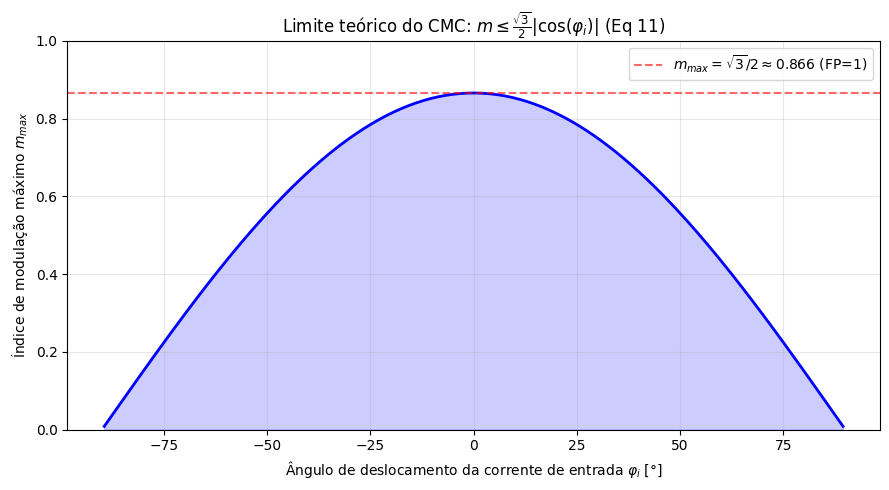

Pontos notáveis:
  φ_i =   0°  →  m_max = 0.8660  (V_out_peak ≤ 86.6% V_in_peak)
  φ_i =  15°  →  m_max = 0.8365  (V_out_peak ≤ 83.7% V_in_peak)
  φ_i =  30°  →  m_max = 0.7500  (V_out_peak ≤ 75.0% V_in_peak)
  φ_i =  45°  →  m_max = 0.6124  (V_out_peak ≤ 61.2% V_in_peak)
  φ_i =  60°  →  m_max = 0.4330  (V_out_peak ≤ 43.3% V_in_peak)
  φ_i =  90°  →  m_max = 0.0000  (V_out_peak ≤ 0.0% V_in_peak)


In [8]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
phi_range = np.linspace(-pi/2 + 0.01, pi/2 - 0.01, 200)
m_max = np.array([svm_max_modulation(phi) for phi in phi_range])

ax.plot(phi_range * 180/pi, m_max, 'b-', lw=2)
ax.axhline(np.sqrt(3)/2, color='r', linestyle='--', alpha=0.6,
            label=f'$m_{{max}} = \\sqrt{{3}}/2 \\approx 0.866$ (FP=1)')
ax.fill_between(phi_range * 180/pi, 0, m_max, alpha=0.2, color='blue')
ax.set_xlabel('Ângulo de deslocamento da corrente de entrada $\\varphi_i$ [°]')
ax.set_ylabel('Índice de modulação máximo $m_{max}$')
ax.set_title('Limite teórico do CMC: $m \\leq \\frac{\\sqrt{3}}{2} |\\cos(\\varphi_i)|$ (Eq 11)')
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("Pontos notáveis:")
for phi_deg in [0, 15, 30, 45, 60, 90]:
    m_max_val = svm_max_modulation(phi_deg * pi/180)
    print(f"  φ_i = {phi_deg:3d}°  →  m_max = {m_max_val:.4f}  "
          f"(V_out_peak ≤ {m_max_val*100:.1f}% V_in_peak)")


## Conclusão

* A SVM analítica do CMC é determinada pelas Eqs 7a-7d da tese,
  com 4 razões cíclicas para 4 vetores ativos + 1 nulo por $T_s$.
* A sequência simétrica (Fig 5) garante baixa DHT e dv/dt moderado.
* O limite teórico $m \le \sqrt{3}/2$ a FP unitário é o "preço" da
  conversão direta CA-CA — em troca, eliminamos o barramento CC
  e ganhamos densidade de potência + operação em 4 quadrantes.

**Próximo notebook**: aplicação dessa SVM analítica no pulsim — L0
ideal (sem chaveamento) vs L1 chaveado, e verificação que o
fundamental de saída casa com o previsto pela análise.
